# India Rainfall Analysis
## Motivation and Description
Monsoon prediction is clearly of great importance for India.Two types of rainfall predictions
can be done, They are
- Long term predictions: Predict rainfall over few weeks/months in advance.
- Short term predictions: Predict rainfall a few days in advance in specific locations.<br>
<p>Indian meteorological department provides forecasting data required for project. 
    In this project we are planning to work on long term predictions of rainfall. 
    The main motive of the project is to predict the amount of rainfall in a particular division or state well in advance. 
    We predict the amount of rainfall using past data.</p>

## Dataset
- Dataset1([dataset1](https://data.gov.in/resources/district-rainfall-normal-mm-monthly-seasonal-and-annual-data-period-1951-2000)) 
  This dataset has average rainfall from 1951-2000 for each district, for every month.
- Dataset2([dataset2](https://data.gov.in/resources/subdivision-wise-rainfall-and-its-departure-1901-2015)) 
  This dataset has average rainfall for every year from 1901-2015 for each state.

## Methodology
- Converting data in to the correct format to conduct experiments.
- Make a good analysis of data and observe variation in the patterns of rainfall.
- Finally, we try to predict the average rainfall by separating data into training and
  testing. We apply various statistical and machine learning approaches(*SVM*,
  etc) in prediction and make analysis over various approaches. By using various
  approaches we try to minimize the error.


In [48]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

## Types of graphs
- Bar graphs showing distribution of amount of rainfall.
- Distribution of amount of rainfall yearly, monthly, groups of months.
- Distribution of rainfall in subdivisions, districts form each month, groups of months.
- Heat maps showing correlation between amount of rainfall between months.


In [49]:
data = pd.read_csv("./district_wise_rainfall_normal.csv",sep=",")
numeric_cols = data.select_dtypes(include=["number"]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   STATE_UT_NAME  641 non-null    object 
 1   DISTRICT       641 non-null    object 
 2   JAN            641 non-null    float64
 3   FEB            641 non-null    float64
 4   MAR            641 non-null    float64
 5   APR            641 non-null    float64
 6   MAY            641 non-null    float64
 7   JUN            641 non-null    float64
 8   JUL            641 non-null    float64
 9   AUG            641 non-null    float64
 10  SEP            641 non-null    float64
 11  OCT            641 non-null    float64
 12  NOV            641 non-null    float64
 13  DEC            641 non-null    float64
 14  ANNUAL         641 non-null    float64
 15  Jan-Feb        641 non-null    float64
 16  Mar-May        641 non-null    float64
 17  Jun-Sep        641 non-null    float64
 18  Oct-Dec   

## Dataset-1 Description
- Data has 36 sub divisions and 19 attributes (individual months, annual, combinations of 3 consecutive months).
- For some of the subdivisions data is from 1950 to 2015.
- All the attributes has the sum of amount of rainfall in mm.

In [50]:
data.head()

,STATE_UT_NAME,DISTRICT,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,354.8,326.0,315.2,250.9,2805.2,165.2,540.7,1207.2,892.1
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,455.6,301.2,275.8,128.3,3015.7,69.7,483.5,1757.2,705.3
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,454.8,276.1,198.6,100.0,2913.3,48.6,405.6,1884.4,574.7
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,313.6,167.1,34.1,29.8,3043.8,123.0,841.3,1848.5,231.0
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,568.0,206.9,29.5,31.7,4034.7,112.8,645.4,3008.4,268.1


In [51]:
data.describe()

,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
count,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.00000,641.000000
mean,18.355070,20.984399,30.034789,45.543214,81.535101,196.007332,326.033697,291.152262,194.609048,90.446334,34.117473,18.150858,1346.969579,39.339470,157.113105,1007.80234,142.714665
std,21.082806,27.729596,45.451082,71.556279,111.960390,196.556284,221.364643,152.647325,99.830540,74.990685,59.371274,32.711009,838.878874,47.212773,213.445888,629.33261,148.951752
min,0.000000,0.000000,0.000000,0.000000,0.900000,3.800000,11.600000,14.100000,8.600000,3.100000,1.200000,0.000000,94.600000,0.000000,1.500000,39.60000,5.600000
25%,6.900000,7.000000,7.000000,5.000000,12.100000,68.800000,206.400000,194.600000,128.800000,34.300000,6.600000,5.300000,830.400000,14.700000,27.800000,625.40000,51.600000
50%,13.300000,12.300000,12.700000,15.100000,33.900000,131.900000,293.700000,284.800000,181.300000,62.600000,12.900000,7.900000,1116.200000,27.700000,67.200000,896.60000,86.700000
75%,19.200000,24.100000,33.200000,48.300000,91.900000,226.600000,374.800000,358.100000,234.100000,130.200000,32.300000,14.900000,1530.900000,41.100000,172.400000,1193.80000,175.200000
max,144.500000,229.600000,367.900000,554.400000,733.700000,1476.200000,1820.900000,1522.100000,826.300000,517.700000,475.100000,297.700000,7229.300000,335.300000,1256.500000,5228.00000,1048.500000


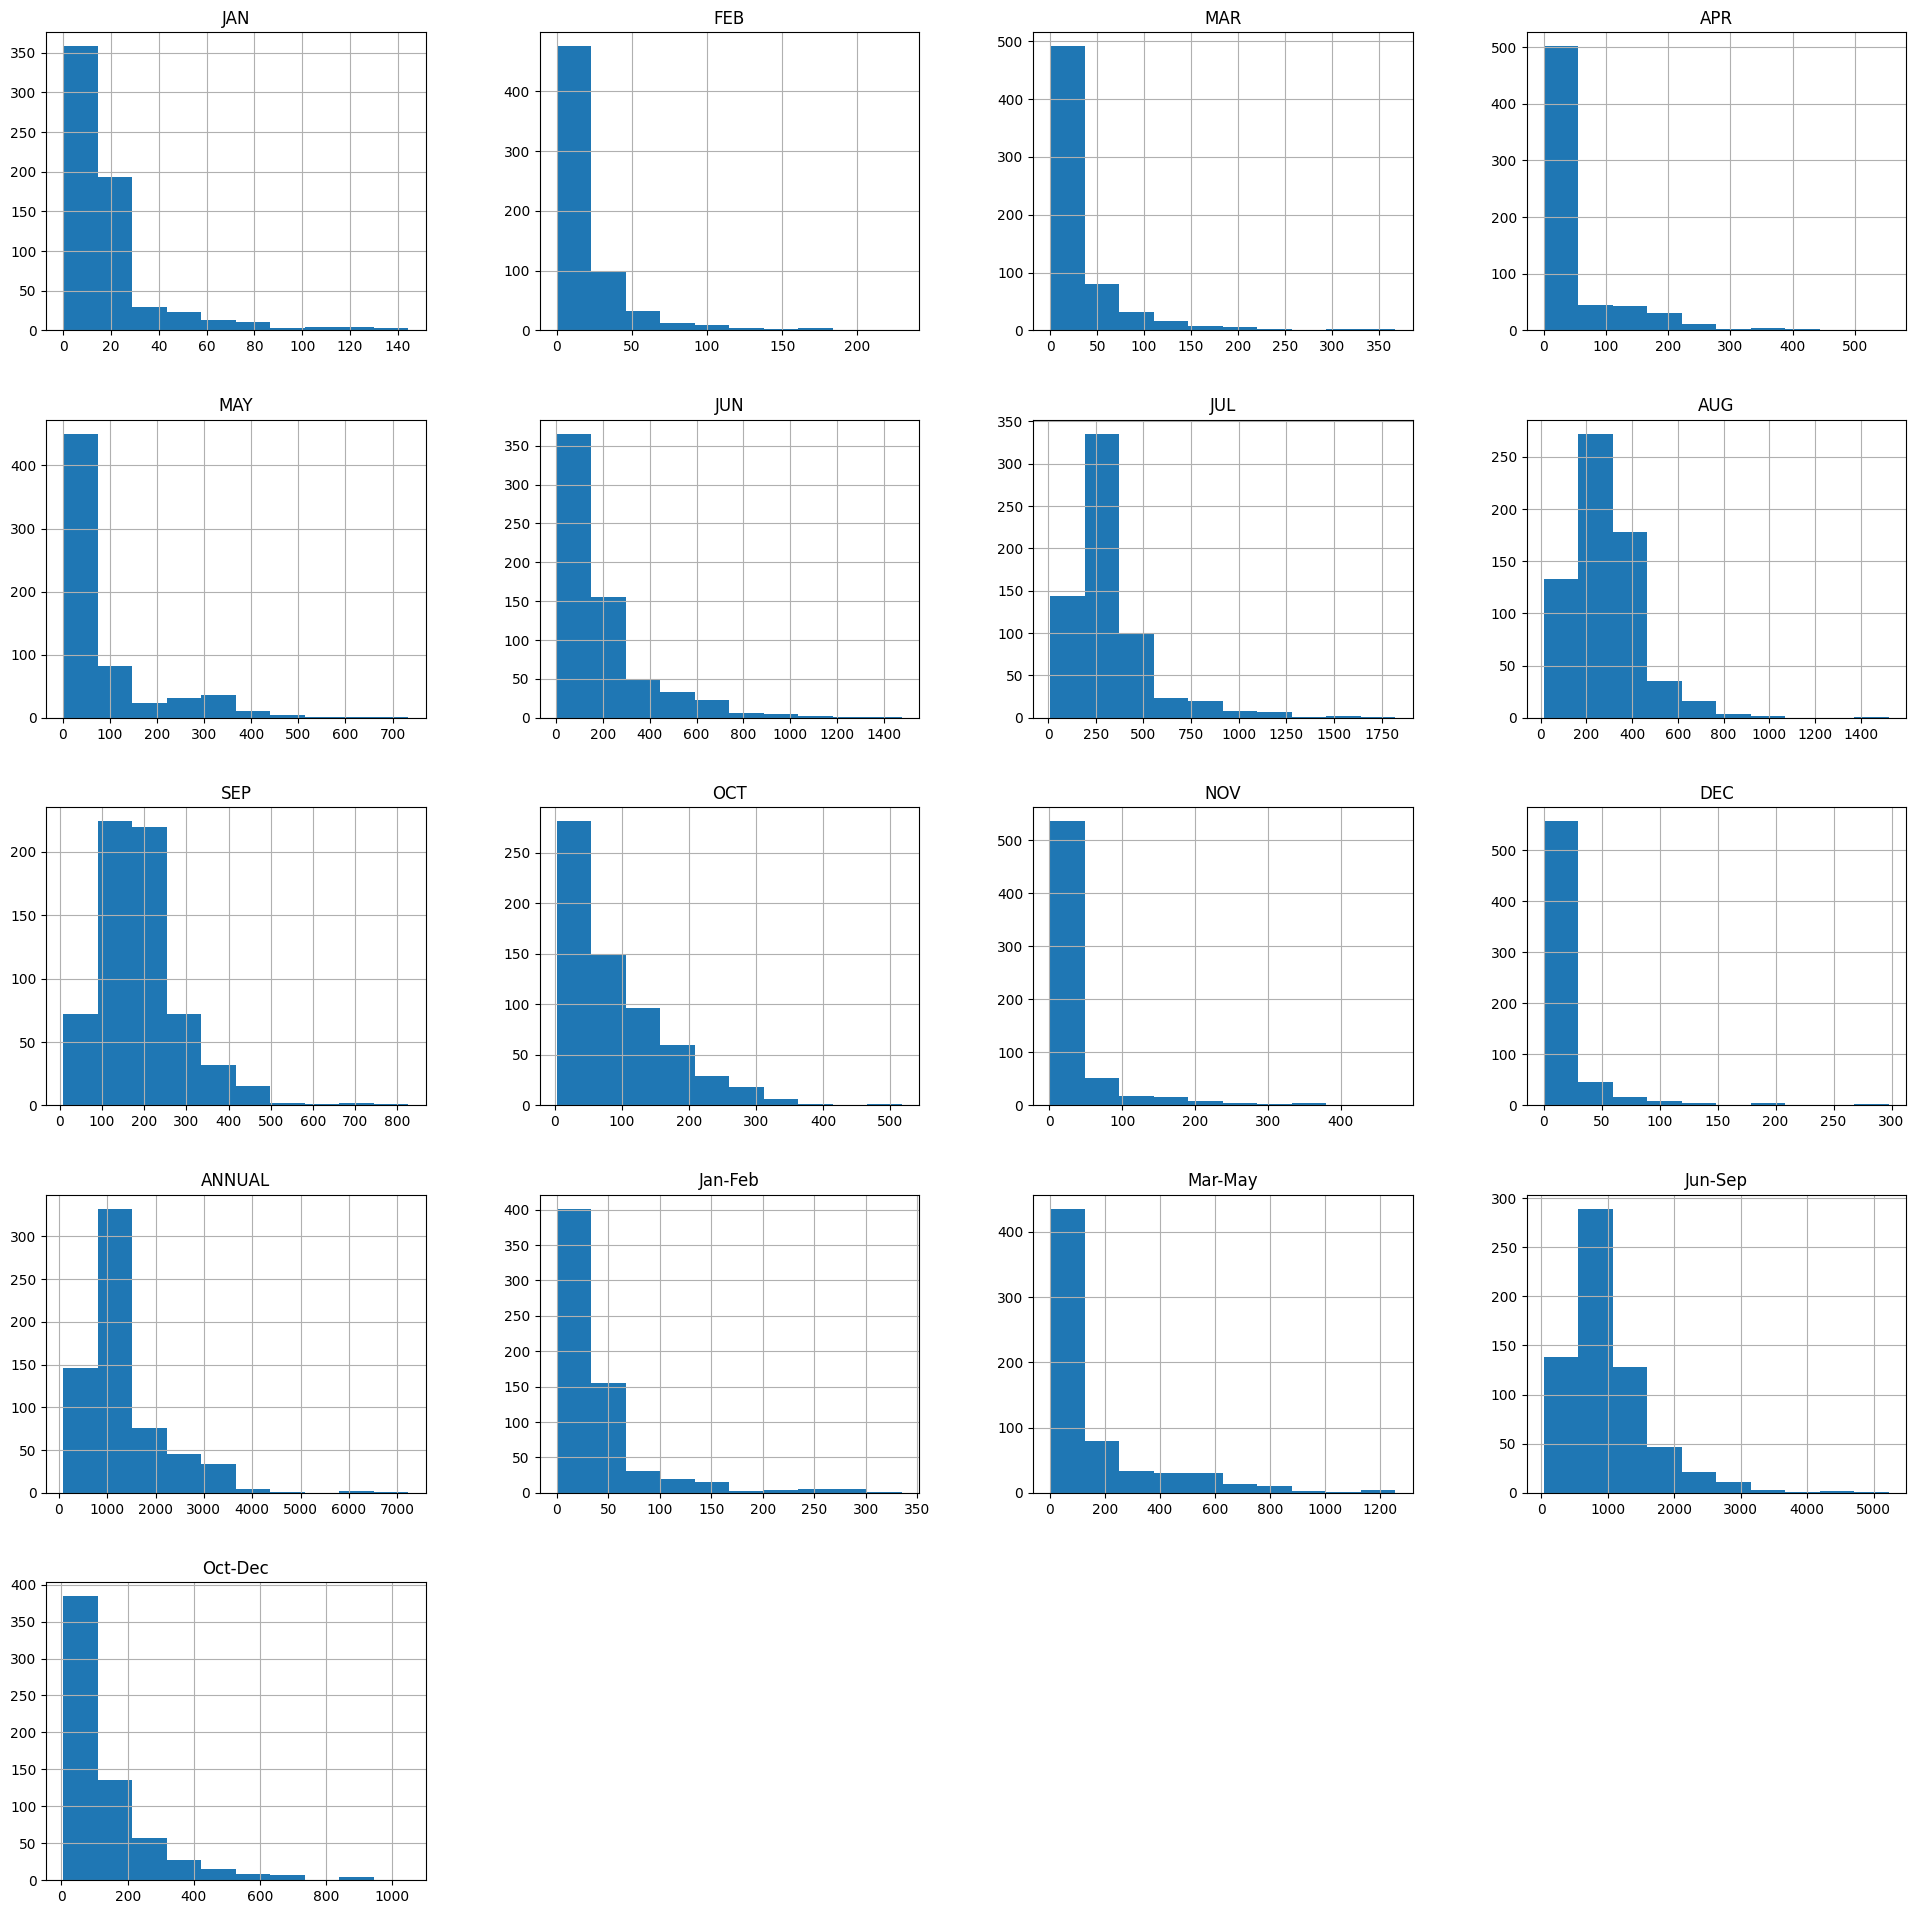

In [52]:
data.hist(figsize=(24,24));

## Observations
- Above histograms show the distribution of rainfall over months.
- Observed increase in amount of rainfall over months July, August, September.

In [53]:
data.groupby("YEAR").sum()['ANNUAL'].plot(figsize=(12,8));

KeyError: 'YEAR'

## Observations
- Shows distribution of rainfall over years. 
- Observed high amount of rainfall in 1950s.

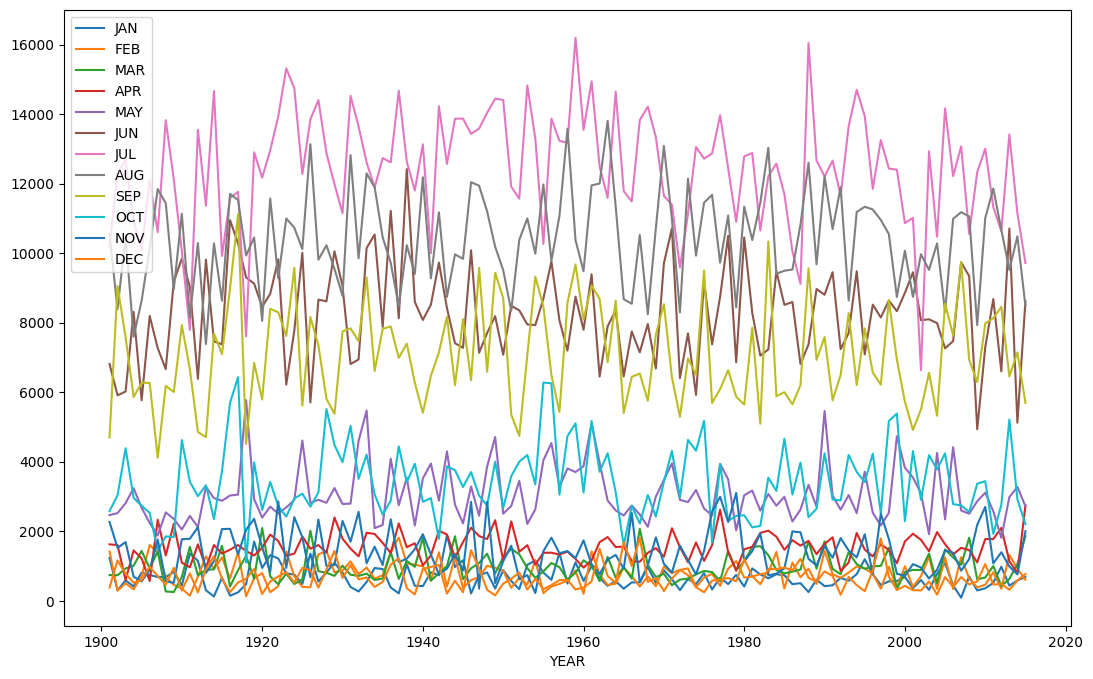

In [ ]:
data[['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].groupby("YEAR").sum().plot(figsize=(13,8));

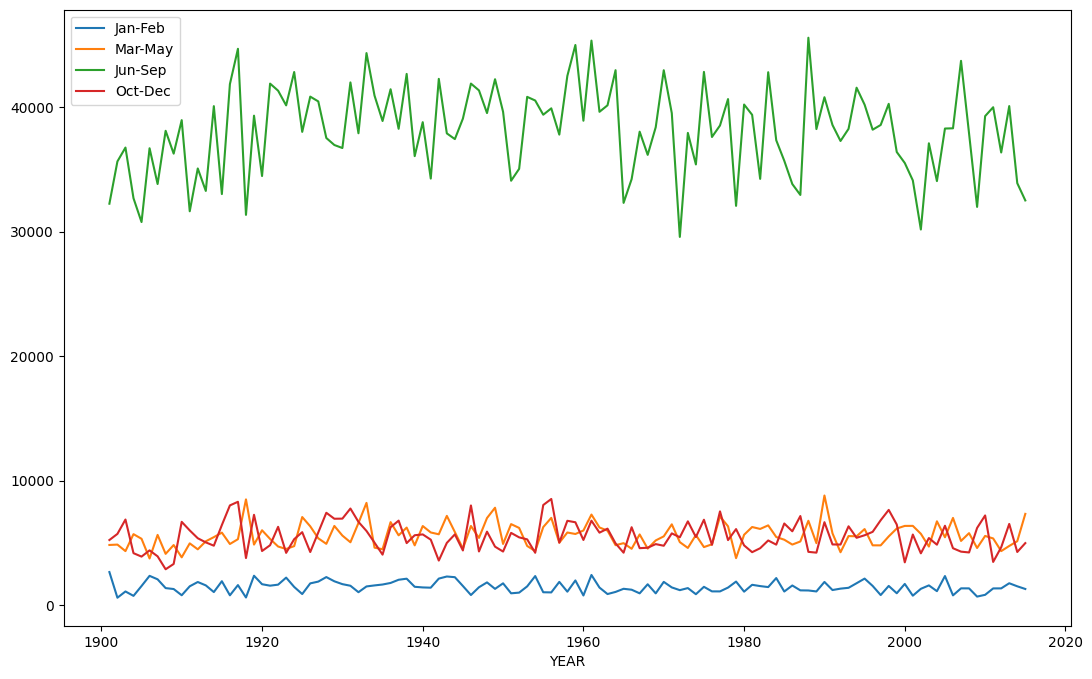

In [ ]:
data[['YEAR','Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec']].groupby("YEAR").sum().plot(figsize=(13,8));

## Observations
- The above two graphs show the distribution of rainfall over months.
- The graphs clearly shows that amount of rainfall in high in the months july, aug, sep which is monsoon season in India.

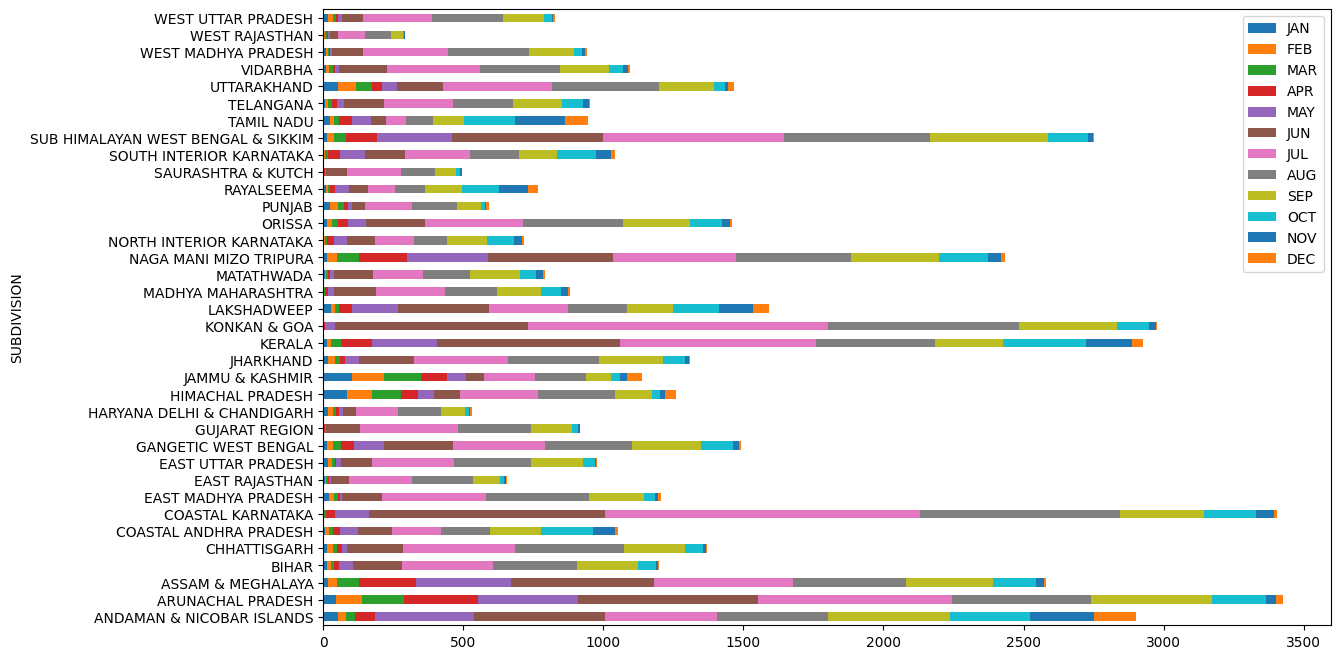

In [ ]:
data[['SUBDIVISION', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].groupby("SUBDIVISION").mean().plot.barh(stacked=True,figsize=(13,8));

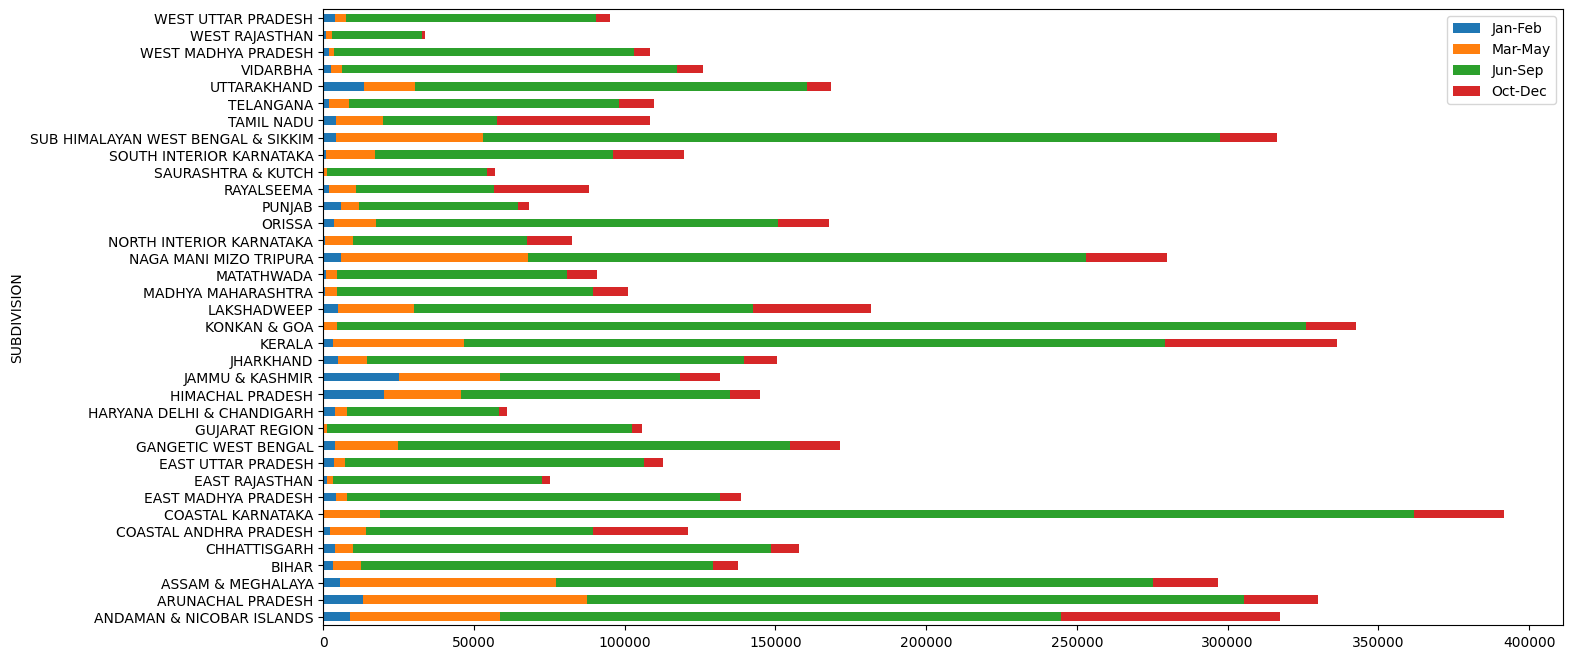

In [ ]:
data[['SUBDIVISION', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec']].groupby("SUBDIVISION").sum().plot.barh(stacked=True,figsize=(16,8));

## Observations
- Above two graphs shows that the amount of rainfall is reasonably good in the months of march, april, may in eastern India. 

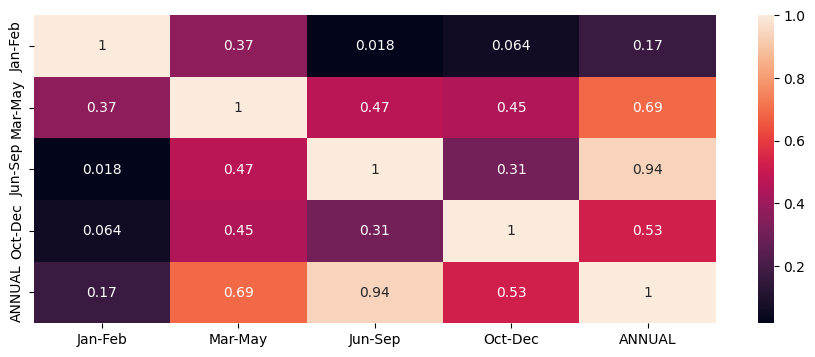

In [ ]:
plt.figure(figsize=(11,4))
sns.heatmap(data[['Jan-Feb','Mar-May','Jun-Sep','Oct-Dec','ANNUAL']].corr(),annot=True)
plt.show()

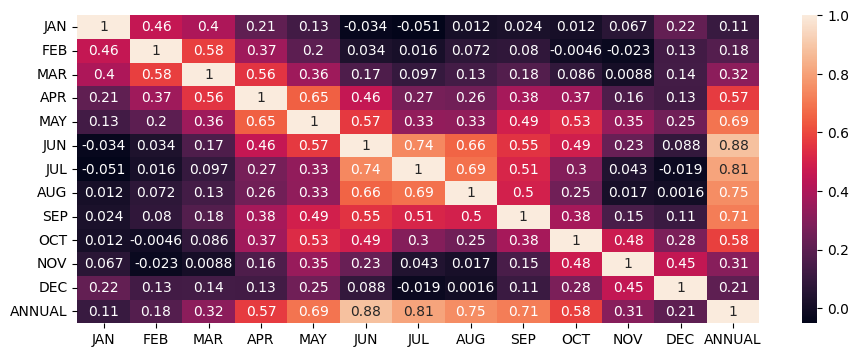

In [ ]:
plt.figure(figsize=(11,4))
sns.heatmap(data[['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC','ANNUAL']].corr(),annot=True)
plt.show()

## Observations
- **Heat Map** shows the co-relation(dependency) betwenn the amounts of rainfall over months.
- From above it is clear that if amount of rainfall is high in the months of july, august, september then the amount of rainfall will be high annually.
- It is also obwserved that if amount of rainfall in good in the months of october, november, december then the rainfall is going to b good in the overall year. 

In [ ]:
#Function to plot the graphs
def plot_graphs(groundtruth,prediction,title):        
    N = 9
    ind = np.arange(N)  # the x locations for the groups
    width = 0.27       # the width of the bars

    fig = plt.figure()
    fig.suptitle(title, fontsize=12)
    ax = fig.add_subplot(111)
    rects1 = ax.bar(ind, groundtruth, width, color='r')
    rects2 = ax.bar(ind+width, prediction, width, color='g')

    ax.set_ylabel("Amount of rainfall")
    ax.set_xticks(ind+width)
    ax.set_xticklabels( ('APR', 'MAY', 'JUN', 'JUL','AUG', 'SEP', 'OCT', 'NOV', 'DEC') )
    ax.legend( (rects1[0], rects2[0]), ('Ground truth', 'Prediction') )

#     autolabel(rects1)
    for rect in rects1:
        h = rect.get_height()
        ax.text(rect.get_x()+rect.get_width()/2., 1.05*h, '%d'%int(h),
                ha='center', va='bottom')
    for rect in rects2:
        h = rect.get_height()
        ax.text(rect.get_x()+rect.get_width()/2., 1.05*h, '%d'%int(h),
                ha='center', va='bottom')
#     autolabel(rects2)

    plt.show()

## Predictions
- For prediction we formatted data in the way, given the rainfall in the last three months we try to predict the rainfall in the next consecutive month.
- For all the experiments we used 80:20 training and test ratio.
    - Linear regression
    - SVR
    - Artificial neural nets
- Tersting metrics: We used Mean absolute error to train the models.
- We also shown the amount of rainfall actually and predicted with the histogram plots.
- We did two types of trainings once training on complete dataset and other with training with only telangana data
- All means are standard deviation observations are written, first one represents ground truth, second one represents predictions.


In [ ]:
# seperation of training and testing data
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

division_data = np.asarray(data[['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']])

X = None; y = None
for i in range(division_data.shape[1]-3):
    if X is None:
        X = division_data[:, i:i+3]
        y = division_data[:, i+3]
    else:
        X = np.concatenate((X, division_data[:, i:i+3]), axis=0)
        y = np.concatenate((y, division_data[:, i+3]), axis=0)
        
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
#test 2010
temp = data[['SUBDIVISION','JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].loc[data['YEAR'] == 2010]

data_2010 = np.asarray(temp[['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].loc[temp['SUBDIVISION'] == 'TELANGANA'])

X_year_2010 = None; y_year_2010 = None
for i in range(data_2010.shape[1]-3):
    if X_year_2010 is None:
        X_year_2010 = data_2010[:, i:i+3]
        y_year_2010 = data_2010[:, i+3]
    else:
        X_year_2010 = np.concatenate((X_year_2010, data_2010[:, i:i+3]), axis=0)
        y_year_2010 = np.concatenate((y_year_2010, data_2010[:, i+3]), axis=0)


In [ ]:
#test 2005
temp = data[['SUBDIVISION','JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].loc[data['YEAR'] == 2005]

data_2005 = np.asarray(temp[['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].loc[temp['SUBDIVISION'] == 'TELANGANA'])

X_year_2005 = None; y_year_2005 = None
for i in range(data_2005.shape[1]-3):
    if X_year_2005 is None:
        X_year_2005 = data_2005[:, i:i+3]
        y_year_2005 = data_2005[:, i+3]
    else:
        X_year_2005 = np.concatenate((X_year_2005, data_2005[:, i:i+3]), axis=0)
        y_year_2005 = np.concatenate((y_year_2005, data_2005[:, i+3]), axis=0)


In [ ]:
#terst 2015
temp = data[['SUBDIVISION','JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].loc[data['YEAR'] == 2015]

data_2015 = np.asarray(temp[['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].loc[temp['SUBDIVISION'] == 'TELANGANA'])

X_year_2015 = None; y_year_2015 = None
for i in range(data_2015.shape[1]-3):
    if X_year_2015 is None:
        X_year_2015 = data_2015[:, i:i+3]
        y_year_2015 = data_2015[:, i+3]
    else:
        X_year_2015 = np.concatenate((X_year_2015, data_2015[:, i:i+3]), axis=0)
        y_year_2015 = np.concatenate((y_year_2015, data_2015[:, i+3]), axis=0)


In [ ]:
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error

# linear model
reg = linear_model.ElasticNet(alpha=0.5)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

# Compute and print mean absolute error
print(mean_absolute_error(y_test, y_pred))

96.32435229744083


MEAN 2005
121.2111111111111 134.68699821349804
Standard deviation 2005
123.77066107608005 90.86310230416439
MEAN 2010
139.93333333333334 144.80501326515912
Standard deviation 2010
135.71320250194282 95.94931363601724
MEAN 2015
88.52222222222223 119.64752006738831
Standard deviation 2015
86.62446123324875 62.36355370163372


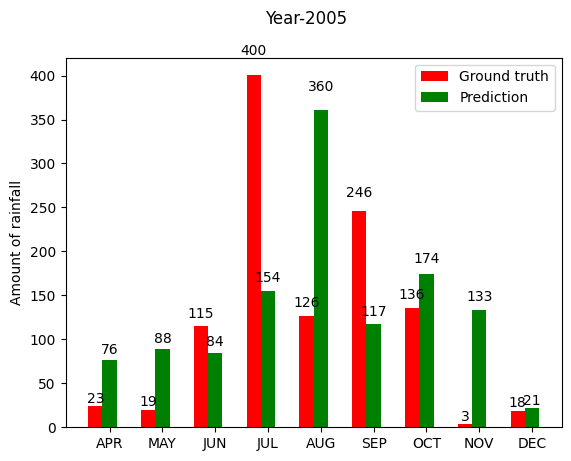

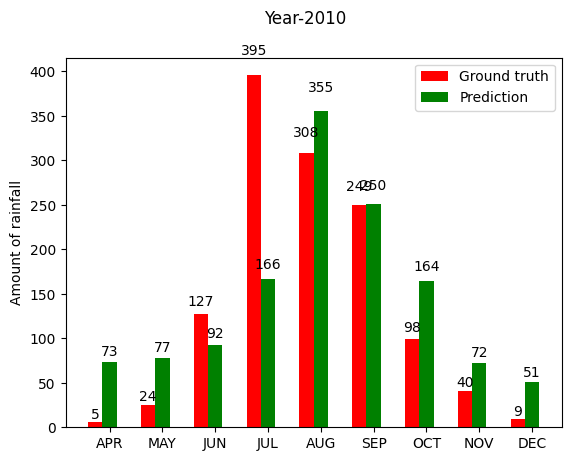

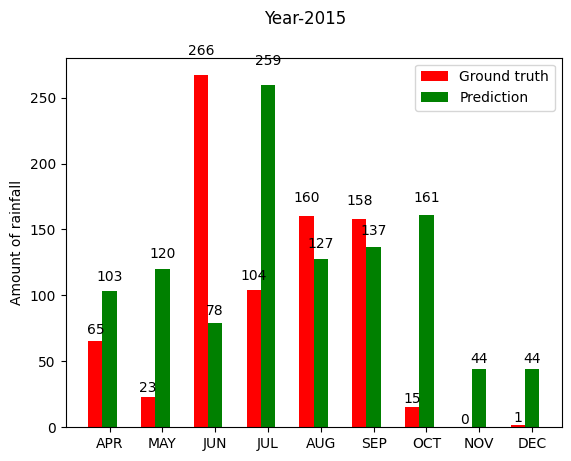

In [ ]:
# 2005
y_year_pred_2005 = reg.predict(X_year_2005)

# 2010
y_year_pred_2010 = reg.predict(X_year_2010)

# 2015
y_year_pred_2015 = reg.predict(X_year_2015)

# Print mean and standard deviation for 2005
print("MEAN 2005")
print(np.mean(y_year_2005), np.mean(y_year_pred_2005))
print("Standard deviation 2005")
print(np.sqrt(np.var(y_year_2005)), np.sqrt(np.var(y_year_pred_2005)))

# Print mean and standard deviation for 2010
print("MEAN 2010")
print(np.mean(y_year_2010), np.mean(y_year_pred_2010))
print("Standard deviation 2010")
print(np.sqrt(np.var(y_year_2010)), np.sqrt(np.var(y_year_pred_2010)))

# Print mean and standard deviation for 2015
print("MEAN 2015")
print(np.mean(y_year_2015), np.mean(y_year_pred_2015))
print("Standard deviation 2015")
print(np.sqrt(np.var(y_year_2015)), np.sqrt(np.var(y_year_pred_2015)))

# Plot graphs
plot_graphs(y_year_2005, y_year_pred_2005, "Year-2005")
plot_graphs(y_year_2010, y_year_pred_2010, "Year-2010")
plot_graphs(y_year_2015, y_year_pred_2015, "Year-2015")

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

# SVM model
clf = SVR(gamma='auto', C=0.1, epsilon=0.2)
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)

# Print mean absolute error
print(mean_absolute_error(y_test, y_pred))

127.1600615632603


MEAN 2005
121.2111111111111 134.68699821349804
Standard deviation 2005
123.77066107608005 90.86310230416439
MEAN 2010
139.93333333333334 144.80501326515912
Standard deviation 2010
135.71320250194282 95.94931363601724
MEAN 2015
88.52222222222223 119.64752006738831
Standard deviation 2015
86.62446123324875 62.36355370163372


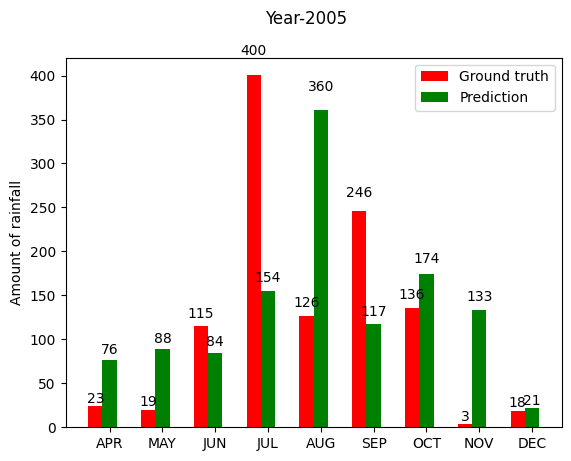

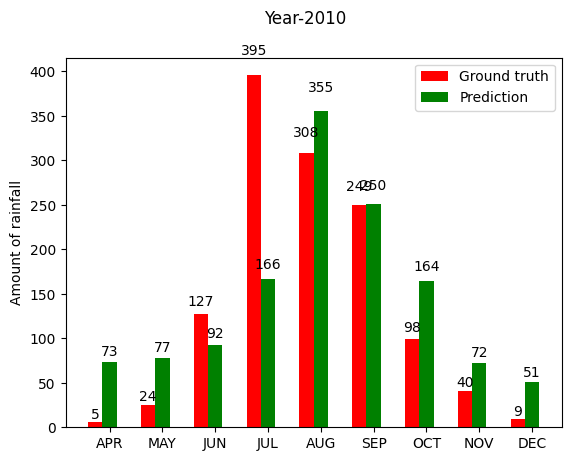

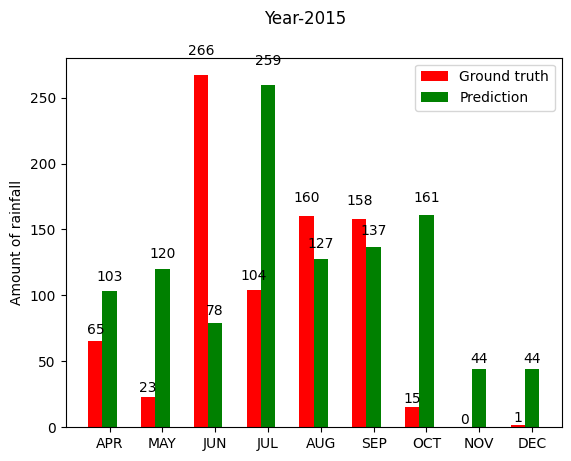

In [ ]:
# 2005
y_year_pred_2005 = reg.predict(X_year_2005)

# 2010
y_year_pred_2010 = reg.predict(X_year_2010)

# 2015
y_year_pred_2015 = reg.predict(X_year_2015)

# Print mean and standard deviation for 2005
print("MEAN 2005")
print(np.mean(y_year_2005), np.mean(y_year_pred_2005))
print("Standard deviation 2005")
print(np.sqrt(np.var(y_year_2005)), np.sqrt(np.var(y_year_pred_2005)))

# Print mean and standard deviation for 2010
print("MEAN 2010")
print(np.mean(y_year_2010), np.mean(y_year_pred_2010))
print("Standard deviation 2010")
print(np.sqrt(np.var(y_year_2010)), np.sqrt(np.var(y_year_pred_2010)))

# Print mean and standard deviation for 2015
print("MEAN 2015")
print(np.mean(y_year_2015), np.mean(y_year_pred_2015))
print("Standard deviation 2015")
print(np.sqrt(np.var(y_year_2015)), np.sqrt(np.var(y_year_pred_2015)))

# Plot graphs
plot_graphs(y_year_2005, y_year_pred_2005, "Year-2005")
plot_graphs(y_year_2010, y_year_pred_2010, "Year-2010")
plot_graphs(y_year_2015, y_year_pred_2015, "Year-2015")

In [ ]:
from keras.models import Model
from keras.layers import Dense, Input, Conv1D, Flatten

# NN model
inputs = Input(shape=(3,1))
x = Conv1D(64, 2, padding='same', activation='elu')(inputs)
x = Conv1D(128, 2, padding='same', activation='elu')(x)
x = Flatten()(x)
x = Dense(128, activation='elu')(x)
x = Dense(64, activation='elu')(x)
x = Dense(32, activation='elu')(x)
x = Dense(1, activation='linear')(x)
model = Model(inputs=[inputs], outputs=[x])
model.compile(loss='mean_squared_error', optimizer='adamax', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 3, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 128)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,353 (298.25 KB)

 Trainable params: 76,353 (298.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x=np.expand_dims(X_train, axis=2), y=y_train, batch_size=64, epochs=10, verbose=1, validation_split=0.1, shuffle=True)
y_pred = model.predict(np.expand_dims(X_test, axis=2))

# Print mean absolute error
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test, y_pred))


Epoch 1/10


c:\Users\hp\anaconda3\envs\scraper\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 3, 1))
  warnings.warn(msg)


469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 22593.9824 - mae: 91.8069 - val_loss: 17668.9258 - val_mae: 84.7582
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 18885.2402 - mae: 86.9852 - val_loss: 17719.8047 - val_mae: 84.8437
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 18583.4824 - mae: 87.1763 - val_loss: 17620.3086 - val_mae: 84.6834
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17847.3945 - mae: 85.6877 - val_loss: 17309.0625 - val_mae: 84.3836
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 17897.6133 - mae: 85.3627 - val_loss: 17544.6523 - val_mae: 86.4530
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 18416.9727 - mae: 85.9805 - val_loss: 17645.9707 - val_mae: 89.0560
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 18151.8652 - mae: 86.5374 - val_loss: 17409.8242 - val_mae: 85.8307
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 18393.5801 - mae: 85.6641 - val_loss: 17201.5156 - val_

c:\Users\hp\anaconda3\envs\scraper\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 3, 1))
  warnings.warn(msg)


116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
87.65346473149596


MEAN 2005
121.2111111111111 134.68699821349804
Standard deviation 2005
123.77066107608005 90.86310230416439
MEAN 2010
139.93333333333334 144.80501326515912
Standard deviation 2010
135.71320250194282 95.94931363601724
MEAN 2015
88.52222222222223 119.64752006738831
Standard deviation 2015
86.62446123324875 62.36355370163372


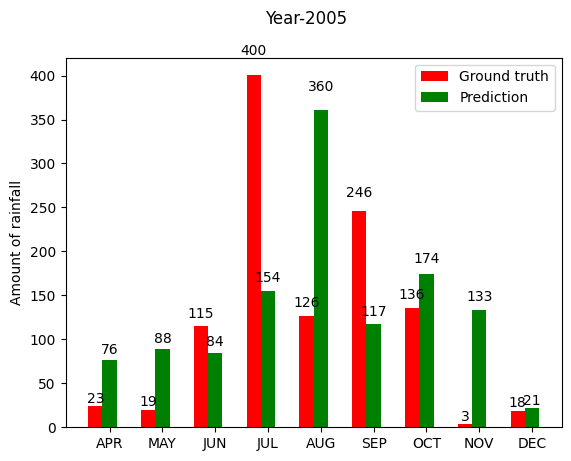

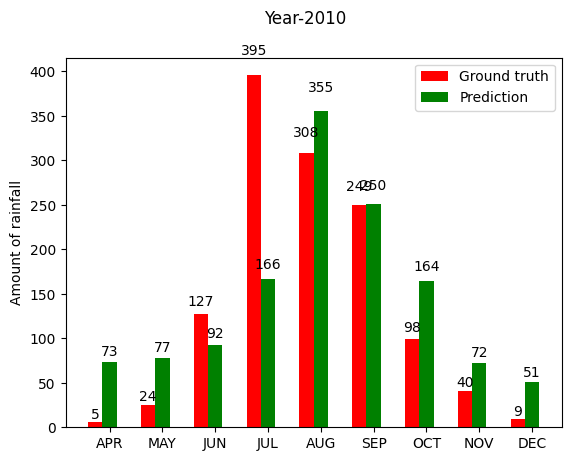

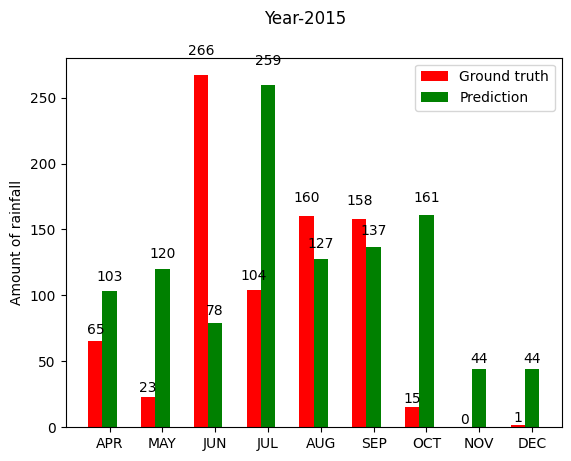

In [ ]:
# 2005
y_year_pred_2005 = reg.predict(X_year_2005)

# 2010
y_year_pred_2010 = reg.predict(X_year_2010)

# 2015
y_year_pred_2015 = reg.predict(X_year_2015)

# Print mean and standard deviation for 2005
print("MEAN 2005")
print(np.mean(y_year_2005), np.mean(y_year_pred_2005))
print("Standard deviation 2005")
print(np.sqrt(np.var(y_year_2005)), np.sqrt(np.var(y_year_pred_2005)))

# Print mean and standard deviation for 2010
print("MEAN 2010")
print(np.mean(y_year_2010), np.mean(y_year_pred_2010))
print("Standard deviation 2010")
print(np.sqrt(np.var(y_year_2010)), np.sqrt(np.var(y_year_pred_2010)))

# Print mean and standard deviation for 2015
print("MEAN 2015")
print(np.mean(y_year_2015), np.mean(y_year_pred_2015))
print("Standard deviation 2015")
print(np.sqrt(np.var(y_year_2015)), np.sqrt(np.var(y_year_pred_2015)))

# Plot graphs
plot_graphs(y_year_2005, y_year_pred_2005, "Year-2005")
plot_graphs(y_year_2010, y_year_pred_2010, "Year-2010")
plot_graphs(y_year_2015, y_year_pred_2015, "Year-2015")

In [ ]:
# spliting training and testing data only for telangana
telangana = np.asarray(data[['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].loc[data['SUBDIVISION'] == 'TELANGANA'])

X = None; y = None
for i in range(telangana.shape[1]-3):
    if X is None:
        X = telangana[:, i:i+3]
        y = telangana[:, i+3]
    else:
        X = np.concatenate((X, telangana[:, i:i+3]), axis=0)
        y = np.concatenate((y, telangana[:, i+3]), axis=0)
        
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42)        

In [ ]:
from sklearn import linear_model

# linear model
reg = linear_model.ElasticNet(alpha=0.5)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print(mean_absolute_error(y_test, y_pred))

64.72601914484643


MEAN 2005
121.2111111111111 106.49798150231581
Standard deviation 2005
123.77066107608005 76.08558540019236
MEAN 2010
139.93333333333334 112.18662987131034
Standard deviation 2010
135.71320250194282 84.35813629737333
MEAN 2015
88.52222222222223 96.76817006572782
Standard deviation 2015
86.62446123324875 52.45304841713268


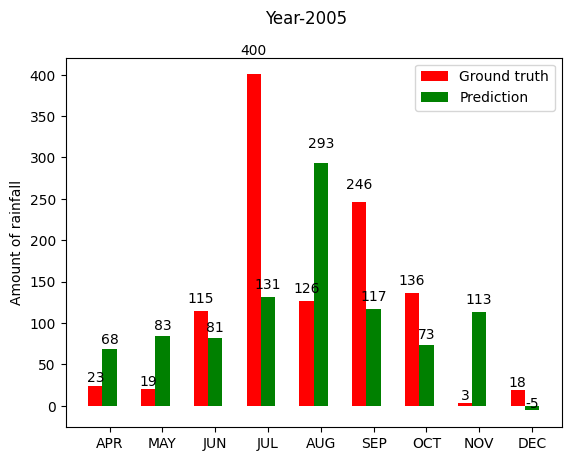

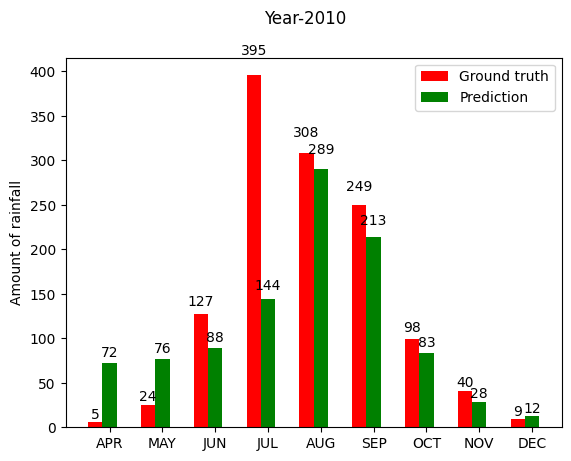

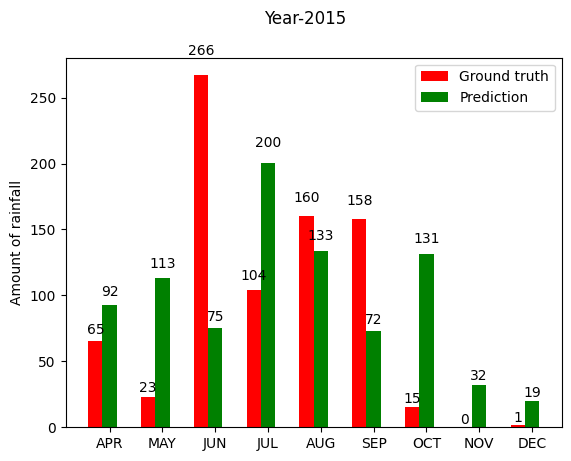

In [ ]:
# 2005
y_year_pred_2005 = reg.predict(X_year_2005)

# 2010
y_year_pred_2010 = reg.predict(X_year_2010)

# 2015
y_year_pred_2015 = reg.predict(X_year_2015)

# Print mean and standard deviation for 2005
print("MEAN 2005")
print(np.mean(y_year_2005), np.mean(y_year_pred_2005))
print("Standard deviation 2005")
print(np.sqrt(np.var(y_year_2005)), np.sqrt(np.var(y_year_pred_2005)))

# Print mean and standard deviation for 2010
print("MEAN 2010")
print(np.mean(y_year_2010), np.mean(y_year_pred_2010))
print("Standard deviation 2010")
print(np.sqrt(np.var(y_year_2010)), np.sqrt(np.var(y_year_pred_2010)))

# Print mean and standard deviation for 2015
print("MEAN 2015")
print(np.mean(y_year_2015), np.mean(y_year_pred_2015))
print("Standard deviation 2015")
print(np.sqrt(np.var(y_year_2015)), np.sqrt(np.var(y_year_pred_2015)))

# Plot graphs
plot_graphs(y_year_2005, y_year_pred_2005, "Year-2005")
plot_graphs(y_year_2010, y_year_pred_2010, "Year-2010")
plot_graphs(y_year_2015, y_year_pred_2015, "Year-2015")

In [ ]:
from sklearn.svm import SVR

# SVM model
clf = SVR(kernel='rbf', gamma='auto', C=0.5, epsilon=0.2)
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print(mean_absolute_error(y_test, y_pred))

115.32415990638656


MEAN 2005
121.2111111111111 106.49798150231581
Standard deviation 2005
123.77066107608005 76.08558540019236
MEAN 2010
139.93333333333334 112.18662987131034
Standard deviation 2010
135.71320250194282 84.35813629737333
MEAN 2015
88.52222222222223 96.76817006572782
Standard deviation 2015
86.62446123324875 52.45304841713268


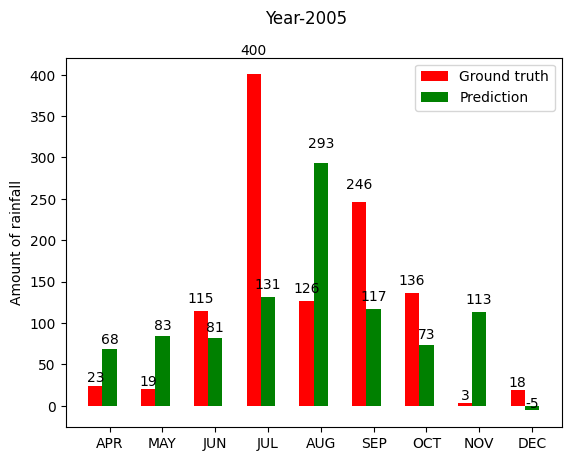

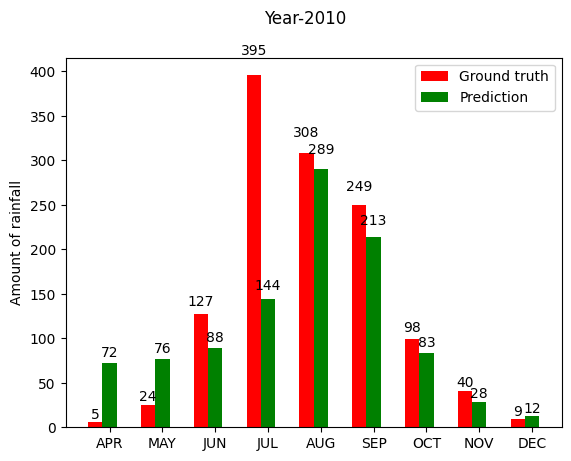

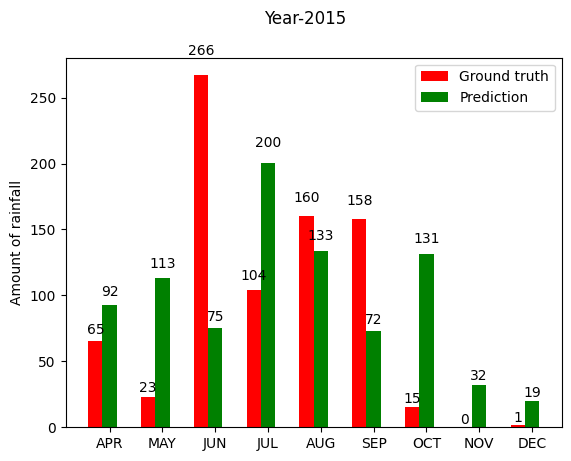

In [ ]:
# 2005
y_year_pred_2005 = reg.predict(X_year_2005)

# 2010
y_year_pred_2010 = reg.predict(X_year_2010)

# 2015
y_year_pred_2015 = reg.predict(X_year_2015)

# Print mean and standard deviation for 2005
print("MEAN 2005")
print(np.mean(y_year_2005), np.mean(y_year_pred_2005))
print("Standard deviation 2005")
print(np.sqrt(np.var(y_year_2005)), np.sqrt(np.var(y_year_pred_2005)))

# Print mean and standard deviation for 2010
print("MEAN 2010")
print(np.mean(y_year_2010), np.mean(y_year_pred_2010))
print("Standard deviation 2010")
print(np.sqrt(np.var(y_year_2010)), np.sqrt(np.var(y_year_pred_2010)))

# Print mean and standard deviation for 2015
print("MEAN 2015")
print(np.mean(y_year_2015), np.mean(y_year_pred_2015))
print("Standard deviation 2015")
print(np.sqrt(np.var(y_year_2015)), np.sqrt(np.var(y_year_pred_2015)))

# Plot graphs
plot_graphs(y_year_2005, y_year_pred_2005, "Year-2005")
plot_graphs(y_year_2010, y_year_pred_2010, "Year-2010")
plot_graphs(y_year_2015, y_year_pred_2015, "Year-2015")

In [ ]:
model.fit(x=np.expand_dims(X_train, axis=2), y=y_train, batch_size=64, epochs=10, verbose=1, validation_split=0.1, shuffle=True)
y_pred = model.predict(np.expand_dims(X_test, axis=2))
print(mean_absolute_error(y_test, y_pred))

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6991.6880 - mae: 63.5716 - val_loss: 4902.0254 - val_mae: 52.0394
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6159.6440 - mae: 58.0024 - val_loss: 4753.4946 - val_mae: 51.1373
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6887.7593 - mae: 60.0453 - val_loss: 4701.7744 - val_mae: 51.4763
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6526.3071 - mae: 58.8016 - val_loss: 4604.0347 - val_mae: 50.6525
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5527.7319 - mae: 54.9711 - val_loss: 4560.2295 - val_mae: 50.3437
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5552.7788 - mae: 53.7794 - val_loss: 4506.4927 - val_mae: 49.8695
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6161.2759 - mae: 56.6479 - val_loss: 4443.0435 - val_mae: 49.6374
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5987.6113 - mae: 57.1792 - val_loss: 4410.5308 - val_mae: 49.6130
Epoch 9

MEAN 2005
121.2111111111111 106.49798150231581
Standard deviation 2005
123.77066107608005 76.08558540019236
MEAN 2010
139.93333333333334 112.18662987131034
Standard deviation 2010
135.71320250194282 84.35813629737333
MEAN 2015
88.52222222222223 96.76817006572782
Standard deviation 2015
86.62446123324875 52.45304841713268


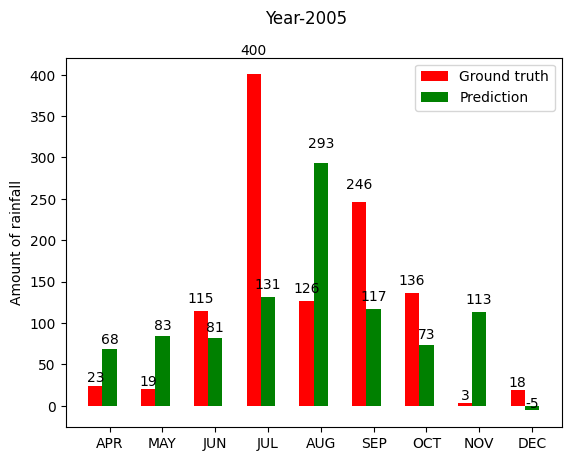

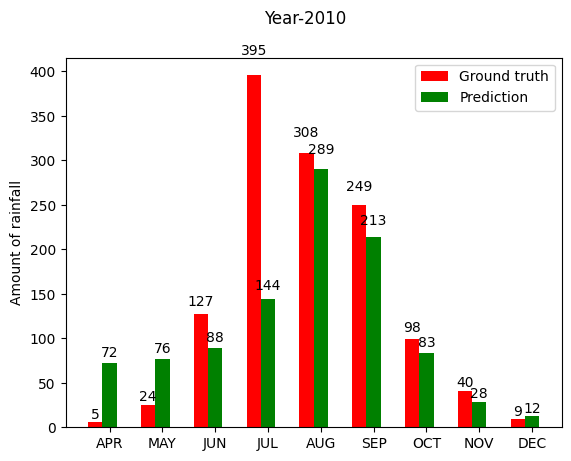

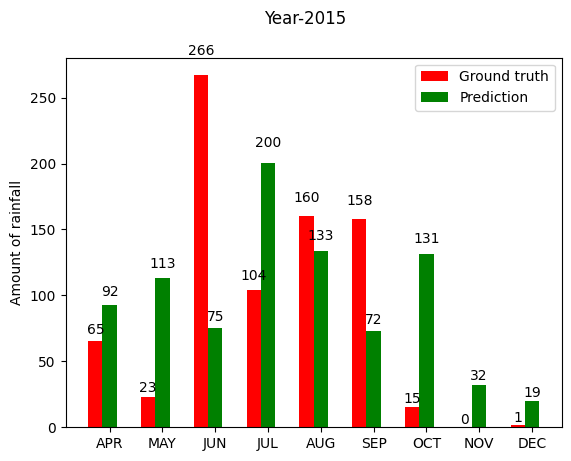

In [ ]:
# 2005
y_year_pred_2005 = reg.predict(X_year_2005)

# 2010
y_year_pred_2010 = reg.predict(X_year_2010)

# 2015
y_year_pred_2015 = reg.predict(X_year_2015)

# Print mean and standard deviation for 2005
print("MEAN 2005")
print(np.mean(y_year_2005), np.mean(y_year_pred_2005))
print("Standard deviation 2005")
print(np.sqrt(np.var(y_year_2005)), np.sqrt(np.var(y_year_pred_2005)))

# Print mean and standard deviation for 2010
print("MEAN 2010")
print(np.mean(y_year_2010), np.mean(y_year_pred_2010))
print("Standard deviation 2010")
print(np.sqrt(np.var(y_year_2010)), np.sqrt(np.var(y_year_pred_2010)))

# Print mean and standard deviation for 2015
print("MEAN 2015")
print(np.mean(y_year_2015), np.mean(y_year_pred_2015))
print("Standard deviation 2015")
print(np.sqrt(np.var(y_year_2015)), np.sqrt(np.var(y_year_pred_2015)))

# Plot graphs
plot_graphs(y_year_2005, y_year_pred_2005, "Year-2005")
plot_graphs(y_year_2010, y_year_pred_2010, "Year-2010")
plot_graphs(y_year_2015, y_year_pred_2015, "Year-2015")

## Prediction Observations

### Training on complete dataset

|Algorithm|MAE|
|---------|---|
|Linear Regression|94.94821727619338|
|SVR|127.74073860203839|
|Artificial neural nets|85.2648713528865|

### Training on telangana dataset

|Algorithm| MAE|
|---------|----|
|Linear Regression| 70.61463829282977|
|SVR| 90.30526775954294|
|Artificial neural nets |59.95190786532157|

- Neural Networks performs better than SVR etc.
- Observed MAE is very high which indicates machine learning models won't work well for prediction of rainfall.
- Telangana data has a single pattern that can be learned by models, rather than learning different patterns of all states. so has high accuracy.
- Analysed individual year rainfall patterns for 2005, 2010, 2015.
- Approximately close means, noticed less standard deviations.

## District wise details
- Similar to above the number of attributes is same, we don’t have year in this.
- The amount of rainfall in mm for each district is added from 1950-2000.
- We analyse the data individually for the state **Andhra Pradesh**


In [ ]:
numeric_columns = district.select_dtypes(include=['float64', 'int64']).columns
# Fill missing values only for numeric columns
district[numeric_columns] = district[numeric_columns].fillna(district[numeric_columns].mean())
district.info()

NameError: name 'district' is not defined

In [ ]:
district.head()

,STATE_UT_NAME,DISTRICT,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN And NICOBAR ISLANDS,NICOBAR,107.3,57.9,65.2,117.0,358.5,295.5,285.0,271.9,354.8,326.0,315.2,250.9,2805.2,165.2,540.7,1207.2,892.1
1,ANDAMAN And NICOBAR ISLANDS,SOUTH ANDAMAN,43.7,26.0,18.6,90.5,374.4,457.2,421.3,423.1,455.6,301.2,275.8,128.3,3015.7,69.7,483.5,1757.2,705.3
2,ANDAMAN And NICOBAR ISLANDS,N & M ANDAMAN,32.7,15.9,8.6,53.4,343.6,503.3,465.4,460.9,454.8,276.1,198.6,100.0,2913.3,48.6,405.6,1884.4,574.7
3,ARUNACHAL PRADESH,LOHIT,42.2,80.8,176.4,358.5,306.4,447.0,660.1,427.8,313.6,167.1,34.1,29.8,3043.8,123.0,841.3,1848.5,231.0
4,ARUNACHAL PRADESH,EAST SIANG,33.3,79.5,105.9,216.5,323.0,738.3,990.9,711.2,568.0,206.9,29.5,31.7,4034.7,112.8,645.4,3008.4,268.1


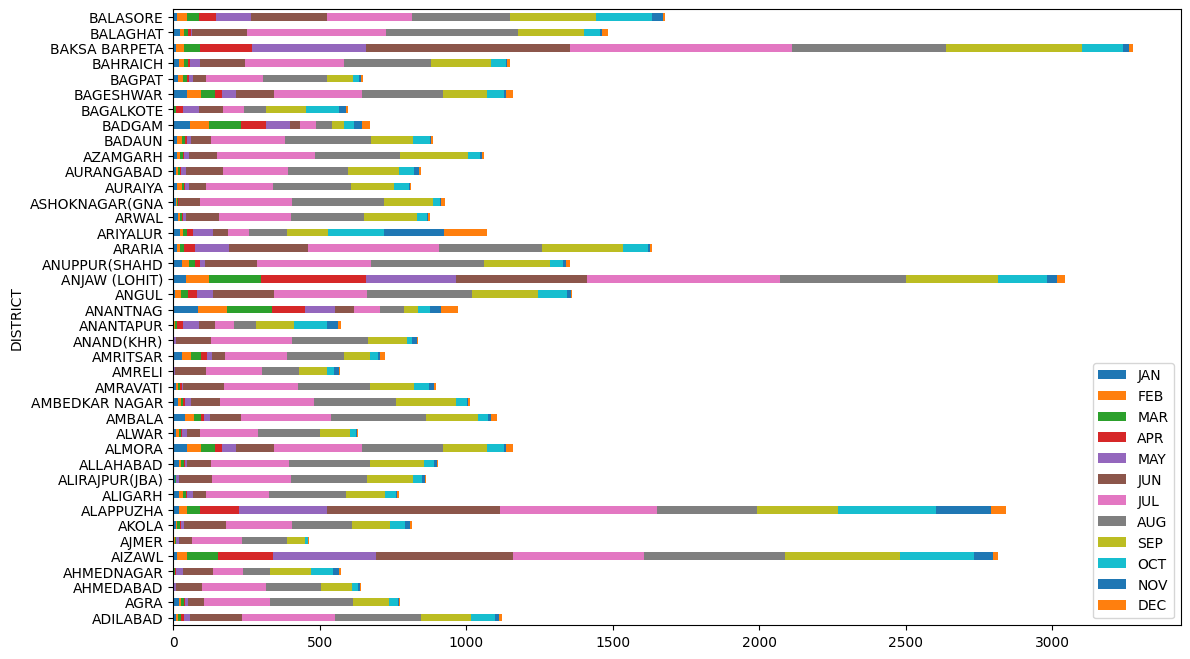

In [ ]:
district[['DISTRICT', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].groupby("DISTRICT").mean()[:40].plot.barh(stacked=True,figsize=(13,8));

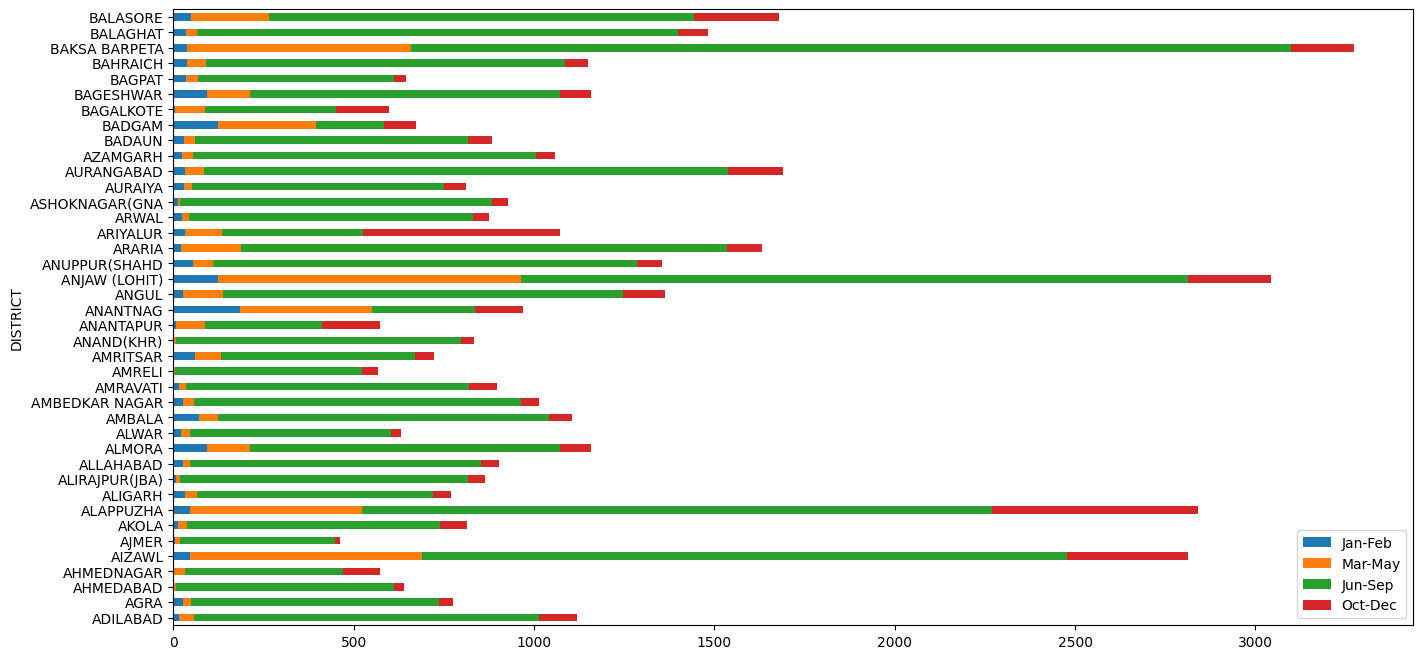

In [ ]:
district[['DISTRICT', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec']].groupby("DISTRICT").sum()[:40].plot.barh(stacked=True,figsize=(16,8));

## Observations
- The above two graphs shows the distribution of over each district.
- As there are large number of districts only 40 were shown in the graphs.

**Andhra Pradesh Data**

In [ ]:
ap_data = district[district['STATE_UT_NAME'] == 'ANDHRA PRADESH']

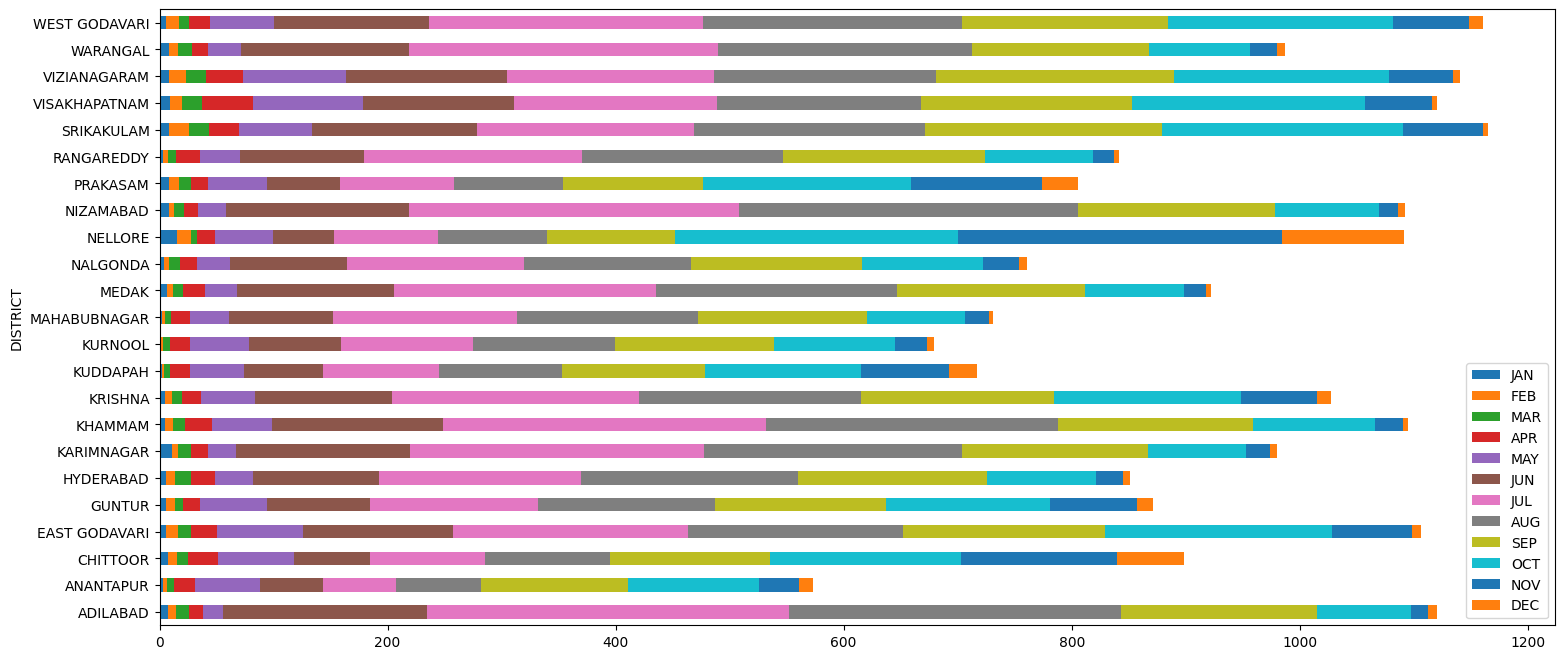

In [ ]:
ap_data[['DISTRICT', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']].groupby("DISTRICT").mean()[:40].plot.barh(stacked=True,figsize=(18,8));

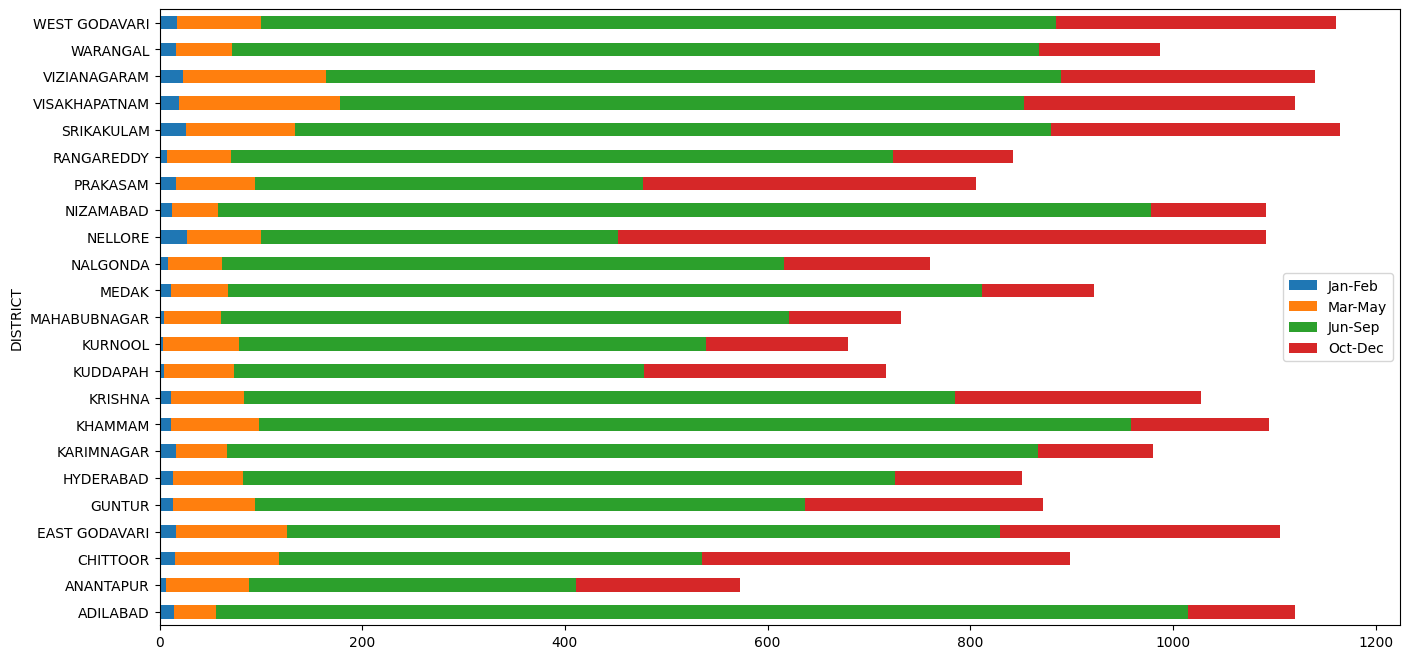

In [ ]:
ap_data[['DISTRICT', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec']].groupby("DISTRICT").sum()[:40].plot.barh(stacked=True,figsize=(16,8));

## Observations
- The above two graphs shows the distribution of over each district in **Andhra Pradesh**.
- The above graphs show that more amount of rainfall is found in srikakulam district, least amount of rainfall is found in Anantapur district.
- It also shows that almost all states have more amount of rainfall have more amount of rainfall in the months june, july, september.

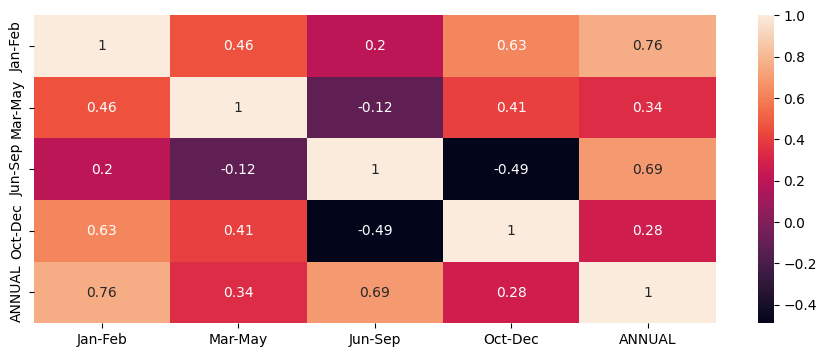

In [ ]:
plt.figure(figsize=(11,4))
sns.heatmap(ap_data[['Jan-Feb','Mar-May','Jun-Sep','Oct-Dec','ANNUAL']].corr(),annot=True)
plt.show()

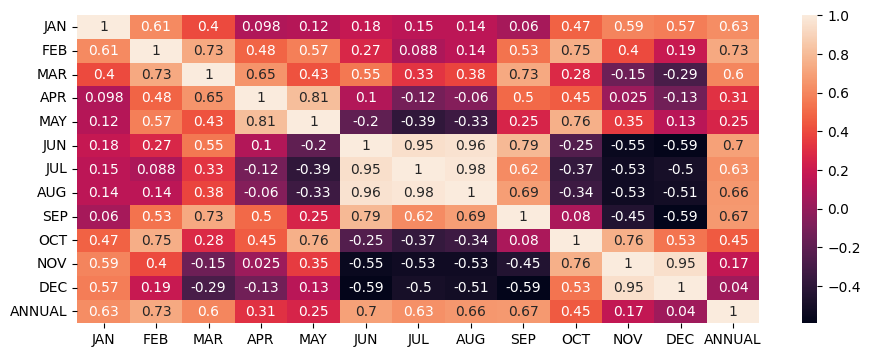

In [ ]:
plt.figure(figsize=(11,4))
sns.heatmap(ap_data[['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC','ANNUAL']].corr(),annot=True)
plt.show()

## Observations
- It is observed that in **Andhra Pradesh**, annual rainfall depends more in the months of january, febuary.
- It also shows that if there is rainfall in months march, april, may then there is less amount of rainfall in the months june, july, august, september.

## Predictions
- We used the same types of models and evaluation metrics used for the above dataset.
- We also tested the amount of rainfall in hyderabad by models trained on complete dataset and andhra pradesh dataset.

In [ ]:
# testing and training for the complete data
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

division_data = np.asarray(district[['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']])

X = None; y = None
for i in range(division_data.shape[1]-3):
    if X is None:
        X = division_data[:, i:i+3]
        y = division_data[:, i+3]
    else:
        X = np.concatenate((X, division_data[:, i:i+3]), axis=0)
        y = np.concatenate((y, division_data[:, i+3]), axis=0)
        
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
temp = district[['DISTRICT','JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL','AUG', 'SEP', 'OCT', 'NOV', 'DEC']].loc[district['STATE_UT_NAME'] == 'ANDHRA PRADESH']
hyd = np.asarray(temp[['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL','AUG', 'SEP', 'OCT', 'NOV', 'DEC']].loc[temp['DISTRICT'] == 'HYDERABAD'])
# print temp
X_year = None; y_year = None
for i in range(hyd.shape[1]-3):
    if X_year is None:
        X_year = hyd[:, i:i+3]
        y_year = hyd[:, i+3]
    else:
        X_year = np.concatenate((X_year, hyd[:, i:i+3]), axis=0)
        y_year = np.concatenate((y_year, hyd[:, i+3]), axis=0)
 

In [ ]:
from sklearn import linear_model

# linear model
reg = linear_model.ElasticNet(alpha=0.5)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print(mean_absolute_error(y_test, y_pred))

57.08862331011229


MEAN Hyderabad
91.48888888888888 108.2025052233288
Standard deviation hyderabad
69.2514651982091 58.90326979488765


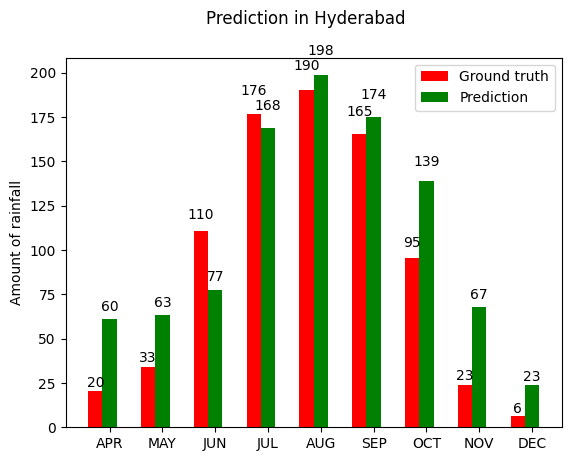

In [ ]:
y_year_pred = reg.predict(X_year)
print("MEAN Hyderabad")
print(np.mean(y_year),np.mean(y_year_pred))
print("Standard deviation hyderabad")
print(np.sqrt(np.var(y_year)),np.sqrt(np.var(y_year_pred)))

plot_graphs(y_year,y_year_pred,"Prediction in Hyderabad")

In [ ]:
from sklearn.svm import SVR

# SVM model
clf = SVR(gamma='auto', C=0.1, epsilon=0.2)
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print(mean_absolute_error(y_test, y_pred))

116.60671510825178


MEAN Hyderabad
91.48888888888888 80.34903236716154
Standard deviation hyderabad
69.2514651982091 0.14736007434982146


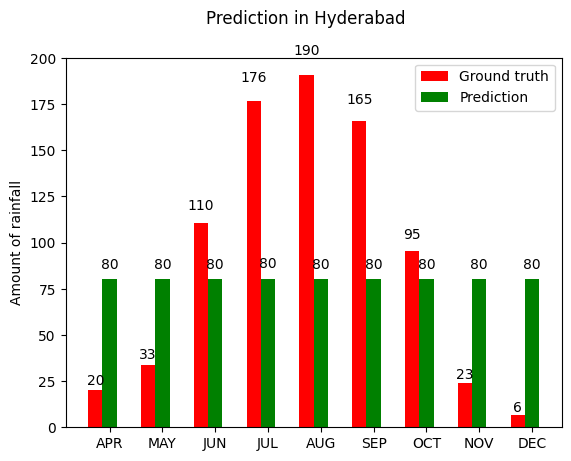

In [ ]:
y_year_pred = clf.predict(X_year)
print("MEAN Hyderabad")
print(np.mean(y_year),np.mean(y_year_pred))
print("Standard deviation hyderabad")
print(np.sqrt(np.var(y_year)),np.sqrt(np.var(y_year_pred)))

plot_graphs(y_year,y_year_pred,"Prediction in Hyderabad")


In [ ]:
model.fit(x=np.expand_dims(X_train, axis=2), y=y_train, batch_size=64, epochs=10, verbose=1, validation_split=0.1, shuffle=True)
y_pred = model.predict(np.expand_dims(X_test, axis=2))
print(mean_absolute_error(y_test, y_pred))

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7957.2988 - mae: 57.5369 - val_loss: 4413.1787 - val_mae: 44.4298
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5298.3257 - mae: 46.1768 - val_loss: 4363.6338 - val_mae: 41.8493
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6500.8735 - mae: 46.8927 - val_loss: 4244.7593 - val_mae: 41.3554
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5008.0205 - mae: 43.3300 - val_loss: 3640.4556 - val_mae: 38.1154
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5498.3438 - mae: 43.3752 - val_loss: 3568.3533 - val_mae: 37.2432
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4845.2710 - mae: 40.8725 - val_loss: 3909.1836 - val_mae: 39.0651
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4845.4741 - mae: 42.4093 - val_loss: 3816.1831 - val_mae: 38.0776
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5237.1836 - mae: 41.7680 - val_loss: 3671.3391 - val_mae: 37.1181
Epoch 9/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


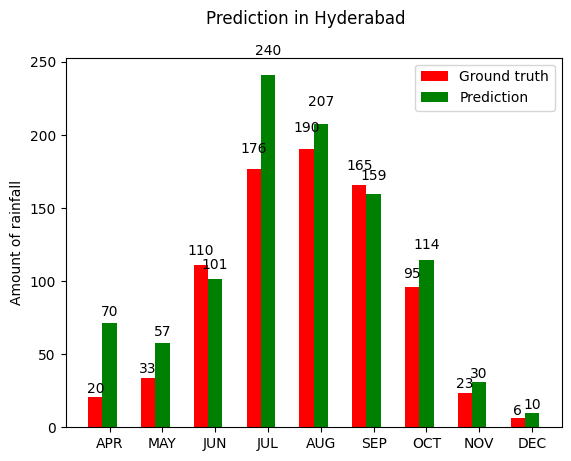

In [ ]:
import numpy as np

# Predict using the model
y_year_pred = model.predict(np.expand_dims(X_year, axis=2))

# Ensure y_year_pred is a 1D array by squeezing any extra dimensions
y_year_pred = np.squeeze(y_year_pred)

# Check that y_year and y_year_pred have the same shape
if len(y_year) == len(y_year_pred):
    plot_graphs(y_year, y_year_pred, "Prediction in Hyderabad")
else:
    print("Shape mismatch: Ensure y_year and y_year_pred have the same number of elements")

In [ ]:
# training and testing sets for only andhra pradesh data
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

division_data = np.asarray(ap_data[['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL',
       'AUG', 'SEP', 'OCT', 'NOV', 'DEC']])

X = None; y = None
for i in range(division_data.shape[1]-3):
    if X is None:
        X = division_data[:, i:i+3]
        y = division_data[:, i+3]
    else:
        X = np.concatenate((X, division_data[:, i:i+3]), axis=0)
        y = np.concatenate((y, division_data[:, i+3]), axis=0)
        
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn import linear_model

# linear model
reg = linear_model.ElasticNet(alpha=0.5)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print(mean_absolute_error(y_test, y_pred))

31.249748674622488


MEAN Hyderabad
91.48888888888888 96.5489199306844
Standard deviation hyderabad
69.2514651982091 60.819355195446896


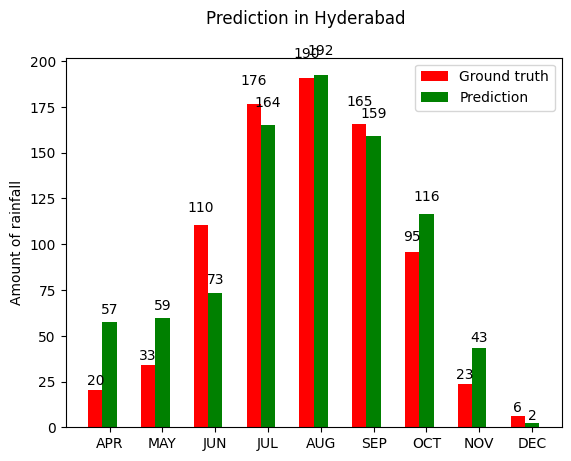

In [ ]:
y_year_pred = reg.predict(X_year)
print("MEAN Hyderabad")
print(np.mean(y_year),np.mean(y_year_pred))
print("Standard deviation hyderabad")
print(np.sqrt(np.var(y_year)),np.sqrt(np.var(y_year_pred)))
plot_graphs(y_year,y_year_pred,"Prediction in Hyderabad")

In [ ]:
from sklearn.svm import SVR

# SVM model
clf = SVR(gamma='auto', C=0.1, epsilon=0.2)
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test)
print(mean_absolute_error(y_test, y_pred))

59.35057496896855


MEAN Hyderabad
91.48888888888888 95.89978206795146
Standard deviation hyderabad
69.2514651982091 0.09247315036320868


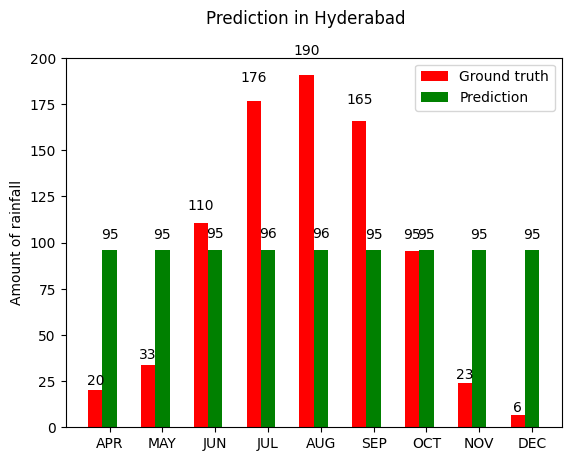

In [ ]:
y_year_pred = clf.predict(X_year)
print("MEAN Hyderabad")
print(np.mean(y_year),np.mean(y_year_pred))
print("Standard deviation hyderabad")
print(np.sqrt(np.var(y_year)),np.sqrt(np.var(y_year_pred)))
plot_graphs(y_year,y_year_pred,"Prediction in Hyderabad")


In [ ]:
model.fit(x=np.expand_dims(X_train, axis=2), y=y_train, batch_size=64, epochs=10, verbose=1, validation_split=0.1, shuffle=True)
y_pred = model.predict(np.expand_dims(X_test, axis=2))
print(mean_absolute_error(y_test, y_pred))

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1917.2662 - mae: 32.5267 - val_loss: 1412.8452 - val_mae: 26.7651
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1941.5825 - mae: 32.3711 - val_loss: 1196.8197 - val_mae: 24.3017
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1724.3225 - mae: 30.6011 - val_loss: 1033.6071 - val_mae: 22.8187
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1526.3721 - mae: 27.5914 - val_loss: 983.8334 - val_mae: 23.6339
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1586.4288 - mae: 27.3861 - val_loss: 985.3907 - val_mae: 23.9210
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1427.4633 - mae: 26.1024 - val_loss: 978.7640 - val_mae: 23.7624
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1410.9236 - mae: 25.8132 - val_loss: 960.9155 - val_mae: 23.3581
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1487.6306 - mae: 25.9696 - val_loss: 957.2839 - val_mae: 22.7596
Epoch 9/10
3/3 ━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
MEAN Hyderabad
91.48888888888888 99.402466
Standard deviation Hyderabad
69.2514651982091 67.17193


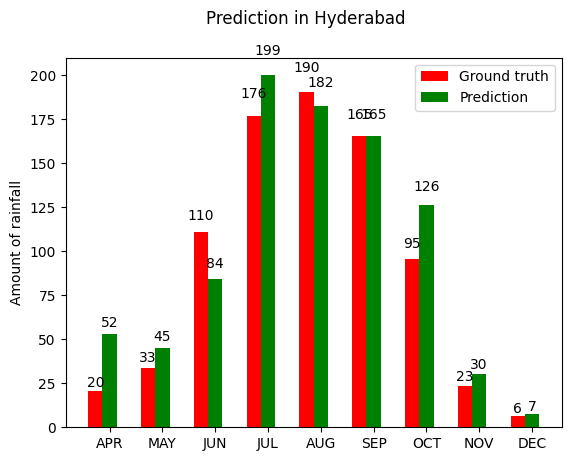

In [ ]:
import numpy as np

# Predict using the model
y_year_pred = model.predict(np.expand_dims(X_year, axis=2))

# Ensure y_year_pred is a 1D array by squeezing any extra dimensions
y_year_pred = np.squeeze(y_year_pred)

# Print mean and standard deviation for both ground truth and predictions
print("MEAN Hyderabad")
print(np.mean(y_year), np.mean(y_year_pred))

print("Standard deviation Hyderabad")
print(np.sqrt(np.var(y_year)), np.sqrt(np.var(y_year_pred)))

# Ensure y_year and y_year_pred have the same length before plotting
if len(y_year) == len(y_year_pred):
    plot_graphs(y_year, y_year_pred, "Prediction in Hyderabad")
else:
    print("Shape mismatch: Ensure y_year and y_year_pred have the same number of elements")

## Prediction Observations

### Training on complete dataset

|Algorithm| MAE|
|---------|----|
|Linear Regression| 57.08862331011236|
|SVR| 116.60671510825178|
|Artificial neural nets |44.329664907381066|

### Training on telangana dataset

|Algorithm| MAE|
|---------|----|
|Linear Regression| 31.249748674622477|
|SVR| 59.35057496896855|
|Artificial neural nets |31.0601823988415|

- Neural Networks performs better than SVR etc.
- Bad performance by SVR model.
- Andhra Pradesh data has a single pattern that can be learned by models, rather than learning different patterns of all states. so has high accuracy.
- Analysed individual year rainfall patterns for Hyderabad district.
- Approximately close means, noticed close standard deviations.

## Conclusions
- Various visualizations of data are observed which helps in implementing the approaches for prediction.
- Prediction of amount of rainfall for both the types of dataset.
- Observations indicates machine learning models won't work well for prediction of rainfall due to fluctutaions in rainfall.

## Technologies
- Programming language : *Python*
- Libraries : *numpy, pandas, matplotlib, seaborn, keras, scipy, sklearn*
